# Simulating microlensing event observed by Rubin 

The goal of this notebook is to simulate the data that Rubin would provide for an exemplar microlensing event, following its normal survey strategy.  

Developed by R. Street, drawing on code from A. Verala

In [49]:
import os
import numpy as np
import pandas as pd
import math
import copy
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column
from astropy.time import Time
from scipy.interpolate import interp1d
#--------------------------------------
import rubin_sim.phot_utils as phot_utils
import rubin_sim.maf as maf
from rubin_sim.phot_utils import signaltonoise, PhotometricParameters
from rubin_sim.data import get_data_dir
from rubin_sim.data import get_baseline
#---------------------------------------
from pyLIMA.simulations import simulator
from pyLIMA import event, toolbox
from pyLIMA import fits as pyLIMA_fits
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.toolbox import fake_telescopes
from pyLIMA.toolbox import plots as pyLIMA_plots_toolbox

## Set up

Rubin Observatory has built sophisticated open-source simulation software, [rubin_sim](https://github.com/lsst/rubin_sim), which has been used to explore alternative observing strategies in order to optimize the survey design.  

Full installation instructions can be found at the link above. 

Rubin_sim provides a range of information about the Rubin telescope and instrument that we'll need for the simulation, so we'll start by loading the information on the filter bandpasses and their expected throughputs.  

In [2]:
# Rubin limiting magnitudes per passband
# Based on https://smtn-002.lsst.io/

zeropoints = {
    'u': 26.52, 
    'g': 28.51, 
    'r': 28.36,
    'i': 28.17, 
    'z': 27.78, 
    'y': 26.82
}

In [3]:
def mag_star(params):
    mags = [float(params[f][0:params[f].index('-')]) for f in ('w','u','g','r','i','z','y')]
    g = [float(params[f][params[f].index('-'):-1]) for f in ('w','u','g','r','i','z','y')]
    return mags, g

def mag(zp, Flux):
    '''
    Transform the flux to magnitude
    inputs
    zp: zero point
    Flux: vector that contains the lightcurve flux
    '''
    return zp-2.5*np.log10(abs(Flux))

def mag_to_flux(mag, mag_err, zeropoints, passband):
    """Function to convert the flux of a star from its fitted PSF model
    and its uncertainty onto the magnitude scale.

    :param float flux: Total star flux
    :param float flux_err: Uncertainty in star flux

    Returns:

    :param float mag: Measured star magnitude
    :param float flux_mag: Uncertainty in measured magnitude
    :param float flux: Total flux, scaled by the exposure time if given
    :param float flux_err: Uncertainty on total flux, scaled by the exposure
                            time, if given
    """

    ZP = zeropoints[passband]

    flux = 10**( (mag - ZP) / -2.5 )

    ferr = mag_err/(2.5*np.log10(np.e)) * flux

    return flux, ferr

def set_photometric_parameters(exptime, nexp, readnoise=None):
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams

In [80]:
LSST_BandPass = {}
lsst_filterlist = 'ugrizy'
for f in lsst_filterlist:
    LSST_BandPass[f] = phot_utils.Bandpass()
    # print(os.path.join(get_data_dir(), 'throughputs', 'baseline', f'total_{f}.dat'))
    LSST_BandPass[f].read_throughput(os.path.join(get_data_dir(), 'throughputs', 'baseline', f'total_{f}.dat'))
photParams = set_photometric_parameters(30,1)
print(dir(photParams))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_bandpass', '_darkcurrent', '_effarea', '_exptime', '_gain', '_nexp', '_othernoise', '_platescale', '_readnoise', '_sigma_sys', 'bandpass', 'darkcurrent', 'effarea', 'exptime', 'gain', 'nexp', 'othernoise', 'platescale', 'readnoise', 'sigma_sys']


## Target details 

Rubin's survey strategy is highly variable, with different cadence and filter choices in different parts of the sky and in different years.  

This section defines an example target.  

In [9]:
# Example star in the Plane but outside of the Bulge
Ra = 281.1125
Dec = -13.88194

# Example star in the RGES DDF
#Ra = 267.92
#Dec = -29.15

peak_time = Time('2026-7-15T10:30:00', format='isot', scale='utc')
t0 = peak_time.jd

In [10]:
# Apparent magnitude of an M-dwarf star at 8kpc, based on extremely approximate colors and extinction, assumed to be grey
Mg = 8.8
Mu = Mg + 2.5
Mr = Mg + 1.0
Mi = Mg + 1.5
Mz = Mg + 2.5
My = Mg + 3.30

d = 6000.0 
A = 0.0

def apparent_mag(M, d, A):
    return M + 5.0 * np.log10(d) - 5.0 + A

mu = apparent_mag(Mu, d, A)
mg = apparent_mag(Mg, d, A)
mr = apparent_mag(Mr, d, A)
mi = apparent_mag(Mi, d, A)
mz = apparent_mag(Mz, d, A)
my = apparent_mag(My, d, A)
print(mu, mg, mr, mi, mz, my)


25.190756251918216 22.690756251918216 23.690756251918216 24.190756251918216 25.190756251918216 25.990756251918217


## Rubin Opsim 

Next, we load the latest simulation of Rubin's survey strategy in operation.   
This contains the details of each simulated observation, including what filter was used to point where in the sky at what time. 

From this information we can construct a set of timestamps of the observations, which we will later use to simulate an event lightcurve.  

In [7]:
baseline_file = '/Users/rstreet/rubin_sim_data/sim_baseline/baseline_v5.0.1_10yrs.db'
name = os.path.basename(baseline_file).replace('.db','')

outDir = 'temp'
resultsDb = maf.db.ResultsDb()

print(baseline_file)
print(name)

bundleList = []
ra = [Ra]
dec = [Dec]
metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])
sql = ''
slicer = maf.slicers.UserPointsSlicer(ra=ra, dec=dec)
bundleList.append(maf.MetricBundle(metric, slicer, sql))

example1_bg = maf.MetricBundleGroup(
    bundleList, baseline_file, out_dir=outDir)
example1_bg.run_all()
dataSlice = bundleList[0].metric_values[0]

filters = ['u', 'g', 'r', 'i', 'z', 'y']

#time_series = {}
#for fil in filters:
#    int_array = np.empty((0, 3), int)
#    for i in range(len(dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == fil)])):
#        m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == fil)][i]
#        mjd = dataSlice['observationStartMJD'][np.where(dataSlice['filter'] == fil)][i] + 2400000.5
#        mags = np.random.uniform(15., m5 - 0.15)
#        int_array = np.append(int_array, [[mjd, m5, m5]], axis=0)
#    time_series[fil] = int_array
#for f, arr in time_series.items():
#    print(f, len(arr[:,0]))


time_series = {}
for fil in filters:
    data = []
    fdx = np.where(dataSlice['filter'] == fil)[0]
    for i in fdx:
        m5 = dataSlice['fiveSigmaDepth'][i]
        mjd = dataSlice['observationStartMJD'][i] + 2400000.5
        mags = np.random.uniform(16., m5 - 0.15)
        mag_err = 0.01
        #flux, flux_error = mag_to_flux(mags, mag_err, zeropoints, fil)
        data.append([mjd, m5, mag_err])
        
    time_series[fil] = np.array(data)
    print(np.array(data)[:,0].min())
print('Filter, N exposures')
for f, arr in time_series.items():
    print(f, len(arr[:,0]))

/Users/rstreet/rubin_sim_data/sim_baseline/baseline_v5.0.1_10yrs.db
baseline_v5.0.1_10yrs
2461206.6939189807
2461156.8171131257
2461156.840937077
2461158.9217400737
2461162.883612653
2461159.8154094233
Filter, N exposures
u 30
g 159
r 179
i 160
z 156
y 43


# LS4 Simulation 

The La Silla Schmidt Southern Survey (LS4)[https://ls4.org/] will be a dedicated survey on the 1m Schmidt telescope with a Wide Field camera.  The public surveys include a Galactic Plane survey.  The exact footprint isn't clear but will be ">1000 sq.deg. of high stellar density" which would cover most of the Galactic plane.   

Here we add simulated lightcurves for this survey.  It's cadence is to take pairs of g+i and i+z every two nights, alternating.  

In [13]:
# Start the LS4 lightcurve around the time of the event.  Note this doesn't take visibility into account. 
xmin = t0-(300/2.0)
xmax = t0+(300/2.0)

i_ts = np.arange(xmin, xmax, 2.0) 
g_ts = np.arange(xmin, xmax, 4.0)
z_ts = np.arange(xmin+2.0, xmax, 4.0) 

ls4_idata = np.zeros((len(i_ts), 3)) 
ls4_idata[:,0] = i_ts 
ls4_idata[:,1] = [mi]*len(i_ts)
ls4_idata[:,2] = [0.01]*len(i_ts)

ls4_gdata = np.zeros((len(g_ts), 3)) 
ls4_gdata[:,0] = g_ts 
ls4_gdata[:,1] = [mg]*len(g_ts)
ls4_gdata[:,2] = [0.01]*len(g_ts)

ls4_zdata = np.zeros((len(z_ts), 3)) 
ls4_zdata[:,0] = z_ts 
ls4_zdata[:,1] = [mz]*len(z_ts)
ls4_zdata[:,2] = [0.01]*len(z_ts)

## Event simulation 

We can now simulate an event lightcurve as seen from Rubin with the timestamps above, including its lightcurves in different filters. 

In [93]:
ulens = event.Event(ra=Ra, dec=Dec)
ulens.name = 'An event observed by Rubin'

LSST_u = telescopes.Telescope(name='u', camera_filter='u', location='Earth', lightcurve=time_series['u'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

LSST_g = telescopes.Telescope(name='g', camera_filter='g', location='Earth', lightcurve=time_series['g'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])


LSST_r = telescopes.Telescope(name='r', camera_filter='r', location='Earth', lightcurve=time_series['r'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'],lightcurve_units = ['JD','mag','mag'])


LSST_i = telescopes.Telescope(name='i', camera_filter='i', location='Earth', lightcurve=time_series['i'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'],lightcurve_units = ['JD','mag','mag'])


LSST_z = telescopes.Telescope(name='z', camera_filter='z', location='Earth', lightcurve=time_series['z'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

LSST_y = telescopes.Telescope(name='y', camera_filter='y', location='Earth', lightcurve=time_series['y'].astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

LS4_g = telescopes.Telescope(name='LS4_g', camera_filter='g', location='Earth', lightcurve=ls4_gdata.astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

LS4_i = telescopes.Telescope(name='LS4_i', camera_filter='i', location='Earth', lightcurve=ls4_idata.astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

LS4_z = telescopes.Telescope(name='LS4_z', camera_filter='z', location='Earth', lightcurve=ls4_zdata.astype(float),
                              lightcurve_names = ['time','mag','err_mag'], lightcurve_units = ['JD','mag','mag'])

ulens.telescopes.append(LSST_u)
ulens.telescopes.append(LSST_g)
ulens.telescopes.append(LSST_r)
ulens.telescopes.append(LSST_i)
ulens.telescopes.append(LSST_z)
ulens.telescopes.append(LSST_y)

ulens.telescopes.append(LS4_g)
ulens.telescopes.append(LS4_i)
ulens.telescopes.append(LS4_z)

ulens.telescopes[0].ld_gamma = 0.5
ulens.telescopes[1].ld_gamma = 0.5
ulens.telescopes[2].ld_gamma = 0.5
ulens.telescopes[3].ld_gamma = 0.5
ulens.telescopes[4].ld_gamma = 0.5
ulens.telescopes[5].ld_gamma = 0.5
ulens.telescopes[6].ld_gamma = 0.5
ulens.telescopes[7].ld_gamma = 0.5
ulens.telescopes[8].ld_gamma = 0.5

# Limiting magnitudes in the different passbands
cero_p = [ 27.03, 28.38, 28.16, 27.85,  27.46, 26.68, 20.9, 20.75, 20.25]
lsst_limiting_mags = {
    'u': 27.03, 
    'g': 28.38, 
    'r': 28.16, 
    'i': 27.85, 
    'z': 27.46, 
    'y': 26.68, 
    'LS4_g': 20.9, 
    'LS4_i': 20.75, 
    'LS4_z': 20.25
}
                      
ulens2 = copy.deepcopy(ulens)

# uniform source with point lenss
params = {'t0': t0, 'u0': 0.005, 'tE': 100,'piEN': 0.3,
          'piEE': 0.1}
print('Event parameters: ', params) 

ulens2_parameters = []
for key in params:
    ulens2_parameters.append(params[key])

ulens2_model = PSPL_model.PSPLmodel(ulens2 ,parallax=['Full', t0])
ulens2_pyLIMA_parameters = ulens2_model.compute_pyLIMA_parameters(ulens2_parameters)

fset = ['u', 'g', 'r', 'i', 'z', 'y']
#magstar = [27.94, 25.112, 23.791, 23.052, 22.687, 22.509]
magstar = [mu, mg, mr, mi, mz, my]
# Rubin detection limits outside the Bulge
mag_limit = [23.7, 24.97, 24.52, 24.13, 23.56, 22.55]
 
mag_offset = -2.3

fs = []
ulens2_flux_parameters = []
np.random.seed(i)
G = []
for m in range(len(magstar)):
    ZP = cero_p[m]
    mag_baseline = magstar[m] + mag_offset
    flux_baseline = 10**((ZP-mag_baseline)/2.5)
    #g = np.random.uniform(0,1)
    g = 0.0 # unblended
    G.append(g)
    f_source = flux_baseline/(1+g)
    fs.append(f_source)
    ulens2_flux_parameters.append(f_source)
    ulens2_flux_parameters.append(g)
ulens2_parameters += ulens2_flux_parameters
ulens2_pyLIMA_parameters = ulens2_model.compute_pyLIMA_parameters(ulens2_parameters)
simulator.simulate_lightcurve(ulens2_model, ulens2_pyLIMA_parameters)

for k in range(len(ulens2.telescopes)):
    model_flux = ulens2_model.compute_the_microlensing_model(ulens2.telescopes[k],
                                                             ulens2_pyLIMA_parameters)['photometry']
    ulens2.telescopes[k].lightcurve['flux'] = model_flux
    
# Generate a well-sampled lightcurve model for plotting
model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(ulens2_model, ulens2_pyLIMA_parameters)[0]
#model_telescope.lightcurve_magnitude["mag"] = magnitude * u.mag

#model_lcs = {}
#for k,f in enumerate(fset):
#    flux_model = my_own_model.compute_the_microlensing_model(model_telescope, pyLIMA_parameters)['photometry']
#    flux_model += my_own_flux_parameters[k]
#    magnitude = toolbox.brightness_transformation.flux_to_magnitude(flux_model)
#    mask = ~np.isnan(magnitude)

#    lc = np.zeros((len(model_telescope.lightcurve_magnitude['time']),2))
#    lc[:,0] = model_telescope.lightcurve_magnitude['time'].value
#    lc[:,1] = magnitude
#    print(f, magnitude.min(), magnitude.max())
    
#    model_lcs[f] = lc

Event parameters:  {'t0': np.float64(2461236.9375), 'u0': 0.005, 'tE': 100, 'piEN': 0.3, 'piEE': 0.1}
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
Parallax(Full) estimated for the telescope LS4_g: SUCCESS
Parallax(Full) estimated for the telescope LS4_i: SUCCESS
Parallax(Full) estimated for the telescope LS4_z: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
Parallax(Full) estimated for the telescope LS4_g: SUCCESS
Parallax(Full) est

/Users/rstreet/software/lsst_bitbucket/venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 23 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/rstreet/software/lsst_bitbucket/venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 23 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/rstreet/software/lsst_bitbucket/venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 23 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/rstreet/software/lsst_bitbucket/venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 127 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/rstreet/software/lsst_bitbucket/venv/lib/python3.11/site-package

In [94]:
def calc_ls4_errors(mag_array):
    """
    Simulate photometric uncertainties for LS4 lightcurves as a function of magnitude 
    """

    error_array = np.zeros(len(mag_array))
    error_array.fill(np.nan)
    
    idx1 = np.where(mag_array >= 14.0)[0] 
    idx2 = np.where(mag_array <= 21.0)[0]
    mask = list(set(idx1).intersection(set(idx2)))
    
    sim_mag = np.array([14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0])
    sim_mag_err = np.array([0.0001, 0.005, 0.01, 0.02, 0.08, 0.2, 0.4, 0.7])

    interp_err = interp1d(sim_mag, sim_mag_err)
    
    error_array[mask] = interp_err(mag_array[mask])

    return error_array

In [95]:
def calc_lsst_errors(mag_array):
    """
    Simulate photometric uncertainties for LSST lightcurves as a function of magnitude 
    """

    error_array = np.zeros(len(mag_array))
    error_array.fill(np.nan)
    
    idx1 = np.where(mag_array >= 16.0)[0] 
    idx2 = np.where(mag_array <= 23.5)[0]
    mask = list(set(idx1).intersection(set(idx2)))
    
    sim_mag = np.array([16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0])
    sim_mag_err = np.array([0.0001, 0.0015, 0.003, 0.005, 0.01, 0.05, 0.1, 0.4, 1.0, 2.0, 2.0])

    interp_err = interp1d(sim_mag, sim_mag_err)
    
    error_array[mask] = interp_err(mag_array[mask])

    return error_array

In [103]:
# PyLIMA plotting function extracted and stripped-down for current purposes
MARKER_SYMBOLS = np.array(
    [['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x'] * 10])
MARKERS_COLORS = plt.rcParams["axes.prop_cycle"]

PLOT_SYMBOLS = ['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x']
PLOT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

LS4_PLOT_COLORS = {
    'LS4_g': '#ff7f0e', 
    'LS4_i': '#d62728', 
    'LS4_z': '#9467bd'
}


def plot_aligned_data(figure_axe, microlensing_model, model_parameters, LSSTBandpass, lsst_limiting_mags, photParams, bokeh_plot=None,
                      plot_unit='Mag'):
    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    # plot aligned data
    index = 0

    list_of_telescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                         pyLIMA_parameters)

    ref_names = []
    ref_locations = []
    ref_magnification = []
    ref_fluxes = []

    for ref_tel in list_of_telescopes:
        if ref_tel.lightcurve is not None:
            model_magnification = microlensing_model.model_magnification(ref_tel,
                                                                         pyLIMA_parameters)

            microlensing_model.derive_telescope_flux(ref_tel, pyLIMA_parameters,
                                                     model_magnification)

            f_source = pyLIMA_parameters['fsource_' + ref_tel.name]
            f_blend = pyLIMA_parameters['fblend_' + ref_tel.name]

            # model_magnification = (model['photometry']-f_blend)/f_source

            ref_names.append(ref_tel.name)
            ref_locations.append(ref_tel.location)
            ref_magnification.append(model_magnification)
            ref_fluxes.append([f_source, f_blend])

    normalized_lc = {} 
    
    for ind, tel in enumerate(microlensing_model.event.telescopes):

        if tel.lightcurve is not None:

            if tel.location == 'Earth':

                ref_index = np.where(np.array(ref_locations) == 'Earth')[0][0]

            else:

                ref_index = np.where(np.array(ref_names) == tel.name)[0][0]

            residus_in_mag = \
                pyLIMA_fits.objective_functions.photometric_residuals_in_magnitude(
                    tel, microlensing_model,
                    pyLIMA_parameters)
            if ind == 0:
                reference_source = ref_fluxes[ind][0]
                reference_blend = ref_fluxes[ind][1]
                index += 1

            # time_mask = [False for i in range(len(ref_magnification[ref_index]))]
            time_mask = []

            for time in tel.lightcurve['time'].value:
                time_index = np.where(list_of_telescopes[ref_index].lightcurve[
                                          'time'].value == time)[0][0]
                time_mask.append(time_index)

            # model_flux = ref_fluxes[ref_index][0] * ref_magnification[ref_index][
            #    time_mask] + ref_fluxes[ref_index][1]
            model_flux = reference_source * ref_magnification[ref_index][
                time_mask] + reference_blend
            magnitude = toolbox.brightness_transformation.ZERO_POINT - 2.5 * \
                        np.log10(model_flux)

            ind_color = ind%len(MARKERS_COLORS.by_key()["color"])
            color = MARKERS_COLORS.by_key()["color"][ind_color]
            marker = str(MARKER_SYMBOLS[0][ind])

            #pyLIMA_plots_toolbox.plot_light_curve_magnitude(tel.lightcurve['time'].value,
            #                                 magnitude + residus_in_mag,
            #                                 tel.lightcurve['err_mag'].value,
            #                                 figure_axe=figure_axe, color=color,
            #                                 marker=marker, name=tel.name)
            mask = np.isfinite(tel.lightcurve['err_mag'].value)
            mags = magnitude[mask] + residus_in_mag[mask]
            
            # Instead of the simulated photometric magnitudes (tel.lightcurve['err_mag'].value[mask]) 
            # use custom function
            if 'LS4' in tel.name:
                mag_err = calc_ls4_errors(mags)
            else:
                mag_err = calc_lsst_errors(mags)
                mag_err = signaltonoise.calc_mag_error_m5(mags, 
                                                                   LSSTBandpass[tel.filter], 
                                                                   lsst_limiting_mags[tel.filter], 
                                                                   photParams)[0]
                
            normalized_lc[tel] = Table([
                Column(name='time', data=tel.lightcurve['time'].value[mask]),
                Column(name='mag', data=mags),
                Column(name='mag_err', data=mag_err)
            ])
    return normalized_lc

In [104]:
def plot_photometric_models(figure_axe, microlensing_model, model_parameters,
                            bokeh_plot=None, plot_unit='Mag'):
    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    list_of_telescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                         pyLIMA_parameters)
    telescopes_names = np.array([i.name for i in microlensing_model.event.telescopes])

    # plot models
    index = 0
    model_lc = {}
    
    for tel in list_of_telescopes:

        if tel.lightcurve is not None:

            magni = microlensing_model.model_magnification(tel, pyLIMA_parameters)
            microlensing_model.derive_telescope_flux(tel, pyLIMA_parameters, magni)

            f_source = pyLIMA_parameters['fsource_' + tel.name]
            f_blend = pyLIMA_parameters['fblend_' + tel.name]

            if index == 0:
                ref_source = f_source
                ref_blend = f_blend
                index += 1

            magnitude =  toolbox.brightness_transformation.ZERO_POINT - 2.5 * \
                        np.log10(ref_source * magni + ref_blend)

            # delta_mag = -2.5 * np.log10(f_source + f_blend) + 2.5 * np.log10(
            ##     ref_source + ref_blend)
            # magnitude -= delta_mag

            name = tel.name

            index_color = np.where(name == telescopes_names)[0][0]
            color = MARKERS_COLORS.by_key()["color"][index_color]

            if tel.location == 'Earth':

                name = tel.location
                linestyle = '-'

            else:

                linestyle = '--'


            model_lc[tel.name] = Table([
                Column(name='time', data=tel.lightcurve['time'].value),
                Column(name='mag', data=magnitude)
            ])

    return model_lc


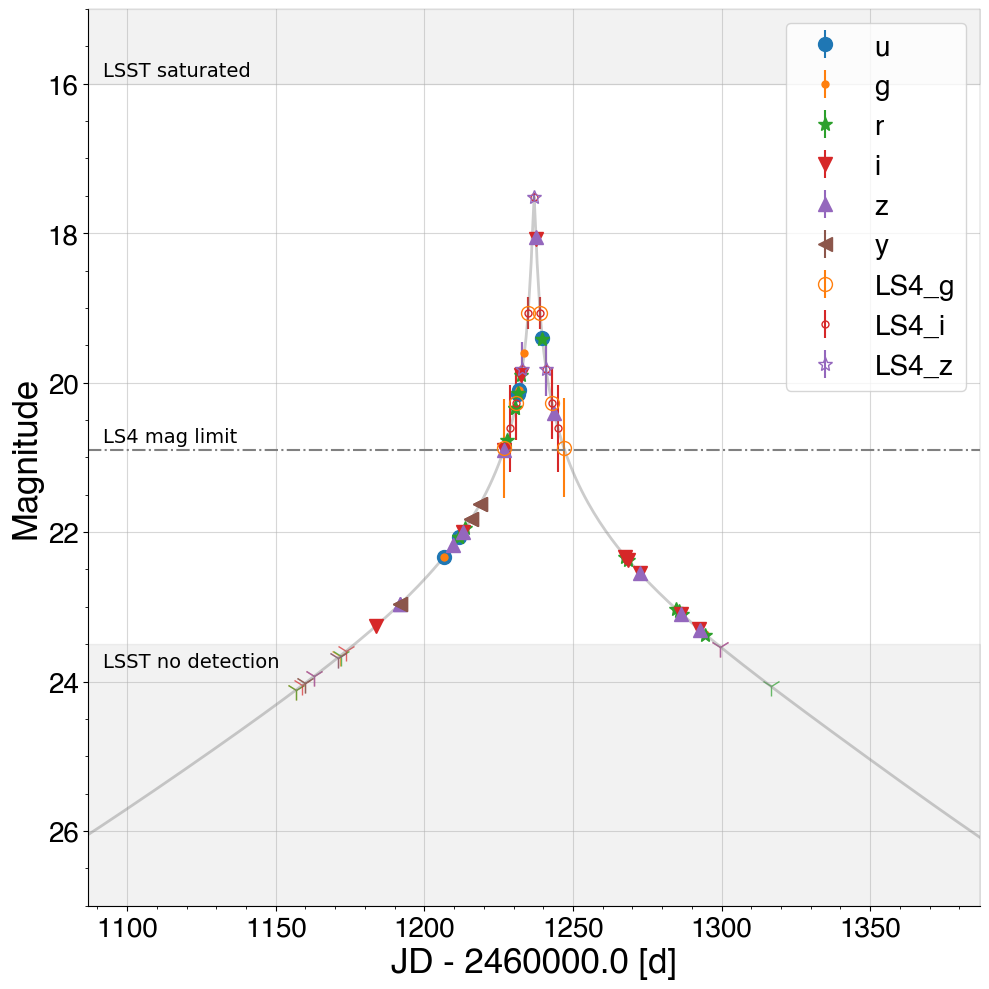

In [110]:
fig2, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
toffset = 2460000.0
limiting_mags = [arr < 20, arr > 40]
#pyLIMA_plots.plot_aligned_data(ax, ulens2_model, ulens2_parameters, bokeh_plot=None,
#                      plot_unit='Mag')
normalized_lc = plot_aligned_data(ax, ulens2_model, ulens2_parameters, LSST_BandPass, lsst_limiting_mags, photParams, bokeh_plot=None, plot_unit='Mag')

model_lc = plot_photometric_models(ax, ulens2_model, ulens2_parameters,
                            bokeh_plot=None, plot_unit='Mag')

i = 0
for tel, data in normalized_lc.items():
    if 'LS4' not in tel.name:
        idx1 = np.where(data['mag'] <= 23.5)[0]
        idx2 = np.where(data['mag'] >= 16.0)[0]
        mask = list(set(idx1).intersection(set(idx2)))
        ax.errorbar(data['time'][mask]-toffset, data['mag'][mask], yerr=data['mag_err'][mask], 
                    color=PLOT_COLORS[i], marker=PLOT_SYMBOLS[i], markersize=10, linestyle='None', alpha=1.0, label=tel.name)
        
        idx1 = list(np.where(data['mag'] > 23.5)[0])
        idx2 = list(np.where(data['mag'] < 16.0)[0])
        mask = idx1 + idx2
        ax.plot(data['time'][mask]-toffset, data['mag'][mask], 
                    color=PLOT_COLORS[i], markerfacecolor='none', marker='1', markersize=15, linestyle='None', alpha=0.7)
        i += 1


# Add LS4 data with limiting magnitudes per passband 
lim_mag = {
    'LS4_g': [14.0, 20.9],
    'LS4_i': [14.0, 20.75],
    'LS4_z': [14.0, 20.25]
}
i = 0
for tel, data in normalized_lc.items():
    if 'LS4' in tel.name:
        min_mag, max_mag = lim_mag[tel.name]
        idx1 = np.where(data['mag'] <= max_mag)[0]
        idx2 = np.where(data['mag'] >= min_mag)[0]
        mask = list(set(idx1).intersection(set(idx2)))
        ax.errorbar(data['time'][mask]-toffset, data['mag'][mask], yerr=data['mag_err'][mask], 
                    color=LS4_PLOT_COLORS[tel.name], marker=PLOT_SYMBOLS[i], 
                    markersize=10, markerfacecolor='none', linestyle='None', alpha=1.0, label=tel.name)
        i += 1

ax.plot(model_lc['u']['time']-toffset, model_lc['u']['mag'], ls='-', lw=2, c='grey', alpha=0.4) 

plt.gca().invert_yaxis()
[xmin, xmax, ymin, ymax] = plt.axis()
ymax = 15.0
ymin = 27.0
xmin = t0-(300/2.0)-toffset
xmax = t0+(300/2.0)-toffset
plt.axis([xmin,xmax,ymin,ymax])

plt.xlabel('JD - 2460000.0 [d]', fontsize=25, fontname="Helvetica", fontweight='ultralight')
plt.ylabel('Magnitude', fontsize=25, fontname="Helvetica", fontweight='ultralight')
ax.tick_params(axis='both', labelsize=20, labelfontfamily="Helvetica") 
ax.minorticks_on() 
plt.grid(alpha=0.5)

legend_font_properties = {
    'family': 'Helvetica', 
    'weight': 'light', 
    'style': 'normal',
    'size': 20
}

plt.legend(prop=legend_font_properties)
ax.spines['right'].set_color('grey')
ax.spines['right'].set_linewidth(0.2)
ax.spines['top'].set_color('grey')
ax.spines['top'].set_linewidth(0.2)
#ax.spines['right'].set_visible(False)

# Shade and annotate LSST non-detection zones and LS4 limiting magnitude
ax.fill_between([xmin,xmax], [ymin], y2=[23.5], color='grey', alpha=0.1)
ax.fill_between([xmin,xmax], [16.0], y2=[ymax], color='grey', alpha=0.1)
ax.text(xmin+5.0, 23.8, 'LSST no detection', fontsize=14)
ax.text(xmin+5.0, 15.9, 'LSST saturated', fontsize=14)
plt.plot([xmin, xmax], [lim_mag['LS4_g'][1], lim_mag['LS4_g'][1]], ls='-.', c='grey')
ax.text(xmin+5.0, lim_mag['LS4_g'][1]-0.1, 'LS4 mag limit', fontsize=14)

#plt.show()
plt.tight_layout()
plt.savefig('/Users/rstreet/cassiopeia/GrantProposals/2025/NSF_AAG/LSSTMicrolensing/figures/lsst_v5_sim_event.png')